# Combined Global / Local fit for pointing recovery

In [1]:
import astropy.units as u
import jax.numpy as jnp
import numpy as np
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

from nyx.atmosphere import single_scattering
from nyx.core import Scene, freeze_all, unfreeze
from nyx.infer import Optimizer
from nyx.core.geometry import Geometry
from nyx.core.observation import Observation
from nyx.emitter import Airglow, Moon, Stars, ZodiacalLight
from nyx.instrument import EffectiveApertureInstrument

JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Building model:

In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 40) * u.nm,  # wavelength grid
    nside=32,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

hess_ct1 = EffectiveApertureInstrument.load("../../data/HESS_CT1.h5", geo)

atmosphere = single_scattering.HGOzoneAbsorption(geo)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0, drift_order=2),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

E0819 12:45:50.585784 1646013 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


## Creating an example observation:

In [3]:
location = EarthLocation.from_geodetic(
    lon=16.5028 * u.deg,
    lat=-23.2728 * u.deg,
    height=1.8 * u.km,
)
times = Time("2021-06-12T02:12:16", scale="utc") + jnp.linspace(0, 30, 120) * 60 * u.s
target = SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic")

obs = Observation(location, times, target, geo)

## Creating target images:

In [4]:
scene = Scene.build(hess_ct1, atmosphere, sources, obs)

# Add random pointing offsets:
nshift = np.deg2rad(np.random.uniform(-0.05, 0.05, size=(scene.nobs["instrument"], 2)))
scene = scene.set("instrument.shift", jnp.array(nshift))

# Add a dimished efficiency:
scene = scene.set("instrument.efficiency", jnp.array([0.7]))

# Add a random flatfielding offset:
pix_efficiency_shift = np.random.lognormal(
    mean=0, sigma=0.1, size=scene.instrument.pixel_efficiency.value.shape
)
scene = scene.set("instrument.pixel_efficiency", jnp.array(pix_efficiency_shift))

In [5]:
rates = scene.render()["instrument"]

rel_error = 0.05  # 5% relative error seems realistic from HMC of flatfielded data
N = 1 / (2 * rel_error**2)
truth_images = rates * np.sqrt(np.random.chisquare(df=N, size=rates.shape) / N)

## Initializing clean scene again:

In [9]:
sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0, drift_order=2),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

scene = Scene.build(hess_ct1, atmosphere, sources, obs)

In [10]:
from nyx.utils.profiler import profile_render

profile_render(scene)


  Render memory profile (backend=gpu, device=cuda:0)
  Memory before render: 197.6 MB
  Memory after render:  198.1 MB
  Peak memory:          5109.7 MB
  Render overhead:      0.4 MB
  Result shape:         (120, 960)
  Output[instrument]:            (120, 960)  float32  0.44 MB

  Device memory (cuda:0):
    In use:     198.1 MB
    Peak:      5109.7 MB
    Limit:    36406.0 MB
    Free:     36207.9 MB



{'before_mb': 197.612548828125,
 'after_mb': 198.052001953125,
 'peak_mb': 5109.67333984375,
 'render_mb': 0.439453125,
 'result_shape': (120, 960)}

## Creating a loss function:

We first prefit using all instrument parameters unfrozen:

In [13]:
%%time
import optimistix as optx

scene = freeze_all(scene)
scene = unfreeze(scene, lambda s: s.instruments["instrument"].shift)
scene = unfreeze(scene, lambda s: s.instruments["instrument"].rotation)
scene = unfreeze(scene, lambda s: s.instruments["instrument"].efficiency)
scene = unfreeze(scene, lambda s: s.airglow.spectral_model.params)


def residuals_fn(scene):
    preds = scene.render()["instrument"]
    return (preds - truth_images) / (truth_images * rel_error)


opt = Optimizer(residuals_fn, optx.LBFGS(rtol=1e-6, atol=1e-6))
fitted, sol = opt.run(scene, max_steps=1024)

CPU times: user 27.9 s, sys: 818 ms, total: 28.7 s
Wall time: 15.6 s


In [14]:
print(
    jnp.sum(residuals_fn(fitted) ** 2) / scene.nobs["instrument"],
    sol.result,
    int(sol.stats["num_steps"]),
)

4713.167 optimistix._solution.RESULTS<> 336


Calculating the errors on our fitted parameters:

In [15]:
%%time
errors = opt.errors(fitted)

CPU times: user 23.2 s, sys: 548 ms, total: 23.8 s
Wall time: 22.5 s


We can see that we get decent results, with the standard deviation being around relatively low

Text(0, 0.5, '$\\Delta$y [arcsec]')

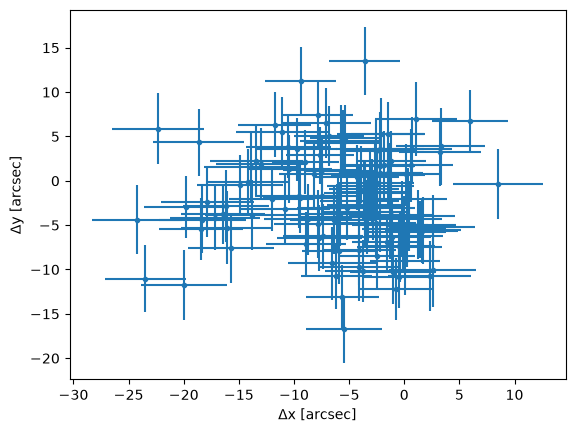

In [16]:
import matplotlib.pyplot as plt

dxdy = np.rad2deg(fitted.instrument.shift.value - nshift) * 3600

dx_err = np.rad2deg(errors.instrument.shift.value[:, 0]) * 3600
dy_err = np.rad2deg(errors.instrument.shift.value[:, 1]) * 3600
plt.errorbar(dxdy[:, 0], dxdy[:, 1], yerr=dy_err, xerr=dx_err, fmt=".")
plt.xlabel(r"$\Delta$x [arcsec]")
plt.ylabel(r"$\Delta$y [arcsec]")

In [17]:
fitted.parameters_table()

name,value,scale,shape,per_obs,frozen,transform
airglow.spectral_model.params,"[-5.8077e-01, +1.0894e+02]",1.00e+02,"(3,)",-,-,-
atmosphere.Mie.angstrom_exp,+1.5000e+00,1.00e+00,(),-,yes,softplus
atmosphere.Mie.aod_500,+1.0000e-01,1.00e+00,(),-,yes,log
atmosphere.Mie.hg_asymmetry,+7.5000e-01,1.00e+00,(),-,yes,tanh
instrument.efficiency,+6.6650e-01,1.00e+00,(),-,-,-
instrument.pixel_efficiency,+1.0000e+00,1.00e+00,"(960,)",-,yes,-
instrument.rotation,"[-3.8583e-03, +2.3318e-03]",1.00e-02,"(120, 1)",yes,-,-
instrument.shift,"[-9.0019e-04, +8.5924e-04]",1.00e-03,"(120, 2)",yes,-,-


The effect of the flatfielding (and us ignoring it in the fitting) leads to our error estimates not having the correct coverage! This shows how important it is to either include the pixel efficiencies in the fit or to have a good flatfielding estimate otherwise.

In [ ]:
normed = np.concatenate([dxdy[:, 0] / dx_err, dxdy[:, 1] / dy_err])

within_1sig = np.mean(np.abs(normed) < 1)  # expect ~68%
within_2sig = np.mean(np.abs(normed) < 2)  # expect ~95%
print(f"1σ: {within_1sig:.0%}, 2σ: {within_2sig:.0%}")

In [ ]:
fitted.parameters_table()